# WEEK 5 - Functions 2, 3, 4, 5, 6

## Exploitative Bayesian Optimization (GP + UCB with β=0)

This notebook uses exploitative Bayesian Optimization to suggest next points for functions 2-6. The approach uses Gaussian Process regression with UCB acquisition function where β=0 (pure exploitation).

### STEP 0 - IMPORT RELEVANT PACKAGES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import data_utils
importlib.reload(data_utils)

# Import utility functions
from data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    combine_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
    plot_bo_visualization_2d,
    plot_function_summary_subplot
)

# Import the exploitative Bayesian Optimization module
from bayesian_optimization_exploitative import SimpleBayesianOptimization

TSNE_RANDOM_STATE = 42

### STEP 1 - LOAD INITIAL DATA

In [2]:
# Load initial data using utility function
base_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/initial_data')
initial_data = load_initial_data(base_dir)

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")

Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


### STEP 2 - LOAD WEEK 1 DATA

In [3]:
# Load week1 data using utility function
week1_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week1')
week1_data = load_week1_data(week1_dir)

print(f"Loaded week1 data for {len(week1_data)} functions")
for function_name, data in week1_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week1 data for 8 functions
  function_1: Input shape = (2,), Output = 2.6752879910742468e-09
  function_2: Input shape = (2,), Output = 0.42721035515778233
  function_3: Input shape = (3,), Output = -0.45300818056360315
  function_4: Input shape = (4,), Output = -25.81769735182645
  function_5: Input shape = (4,), Output = 4219.157963029058
  function_6: Input shape = (5,), Output = -2.6736180536592746
  function_7: Input shape = (6,), Output = 0.013680510023283559
  function_8: Input shape = (8,), Output = 6.0739207860211


### STEP 3 - LOAD WEEK 2 DATA

In [4]:
# Load week2 data using utility function
week2_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week2')
week2_data = load_week2_data(week2_dir)

print(f"Loaded week2 data for {len(week2_data)} functions")
for function_name, data in week2_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week2 data for 8 functions
  function_1: Input shape = (2,), Output = 2.308810742126141e-248
  function_2: Input shape = (2,), Output = 0.09143573616583116
  function_3: Input shape = (3,), Output = -0.16648410423830667
  function_4: Input shape = (4,), Output = 0.07635232865804342
  function_5: Input shape = (4,), Output = 4139.609565498906
  function_6: Input shape = (5,), Output = -1.732308297257106
  function_7: Input shape = (6,), Output = 1.9964705720993239
  function_8: Input shape = (8,), Output = 9.8362097005135


### STEP 4 - LOAD WEEK 3 DATA

In [5]:
# Load week3 data using utility function
week3_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week3')
week3_data = load_week3_data(week3_dir)

print(f"Loaded week3 data for {len(week3_data)} functions")
for function_name, data in week3_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week3 data for 8 functions
  function_1: Input shape = (2,), Output = 0.025559285339829783
  function_2: Input shape = (2,), Output = 0.3317119096486708
  function_3: Input shape = (3,), Output = -0.16364425027712573
  function_4: Input shape = (4,), Output = -2.443739075344467
  function_5: Input shape = (4,), Output = 4205.41112909808
  function_6: Input shape = (5,), Output = -1.2341261163607111
  function_7: Input shape = (6,), Output = 0.8888266866145418
  function_8: Input shape = (8,), Output = 9.9008337717904


### STEP 5 - LOAD WEEK 4 DATA

In [6]:
# Load week4 data using utility function
week4_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week4')
week4_data = load_week4_data(week4_dir)

print(f"Loaded week4 data for {len(week4_data)} functions")
for function_name, data in week4_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week4 data for 8 functions
  function_1: Input shape = (2,), Output = -1.147039773167018e-58
  function_2: Input shape = (2,), Output = 0.3737737205169543
  function_3: Input shape = (3,), Output = -0.15055016501019017
  function_4: Input shape = (4,), Output = -0.05937246575917099
  function_5: Input shape = (4,), Output = 1072.3460141230023
  function_6: Input shape = (5,), Output = -2.002317401777197
  function_7: Input shape = (6,), Output = 2.7733922523082737
  function_8: Input shape = (8,), Output = 9.821645117996


### FUNCTION 2 - EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 2 - COMBINED DATA

Combined inputs shape: (14, 2)
Combined outputs shape: (14,)

Best observed output so far: 0.611205
Mean output: 0.252205
Std output: 0.205305


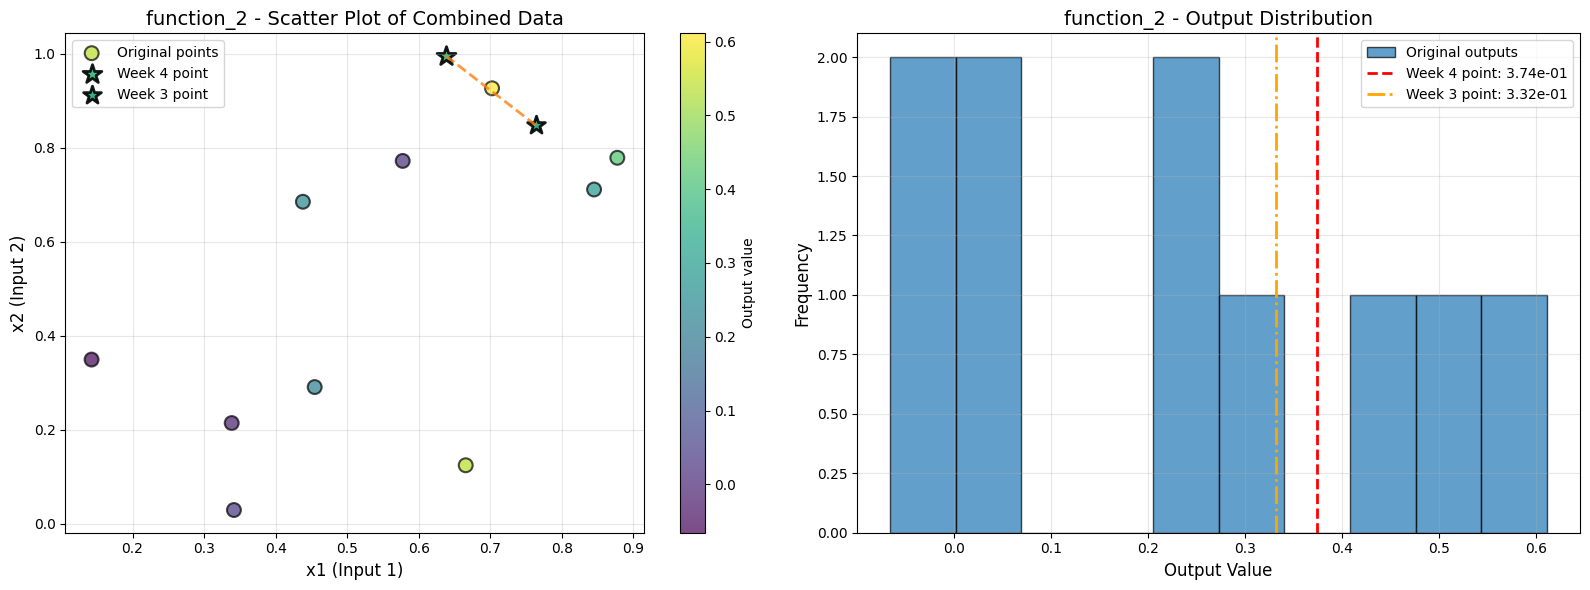

In [7]:
# Function 2 - Combine all data (initial + week 1 + week 2 + week 3 + week 4)
function_name = 'function_2'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output])
])

print("=" * 60)
print(f"FUNCTION 2 - COMBINED DATA")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print("=" * 60)

# Visualize: show week 3 and week 4 points
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs,
    week4_input, week4_output,
    function_name,
    prior_input=week3_input,
    prior_output=week3_output,
    prior_point_label="Week 3 point",
    new_point_label="Week 4 point",
    connect_points=True,
    connect_color="tab:orange"
    
)

In [ ]:
# Function 2 - Run Exploitative Bayesian Optimization
function_name = 'function_2'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create BO object with beta=0 for pure exploitation
bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point using UCB with beta=0.0 (pure exploitation)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print(f"FUNCTION 2 - EXPLOITATIVE BO SUGGESTION (β=0)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0 = mean): {ucb_value:.6f}")
print("=" * 60)

# Save to JSON
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "exploitative_bayesian_optimization",
    "beta": 0.0,
    "expected_value": float(ucb_value)
}

output_path = 'results/function2_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")


FUNCTION 2 - EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.696761-0.934107
Expected value (UCB with β=0 = mean): 0.614920

Result saved to: function2_next_point.json


### FUNCTION 3 - EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 3 - COMBINED DATA

Combined inputs shape: (19, 3)
Combined outputs shape: (19,)

Best observed output so far: -0.034835
Mean output: -0.133747
Std output: 0.107887


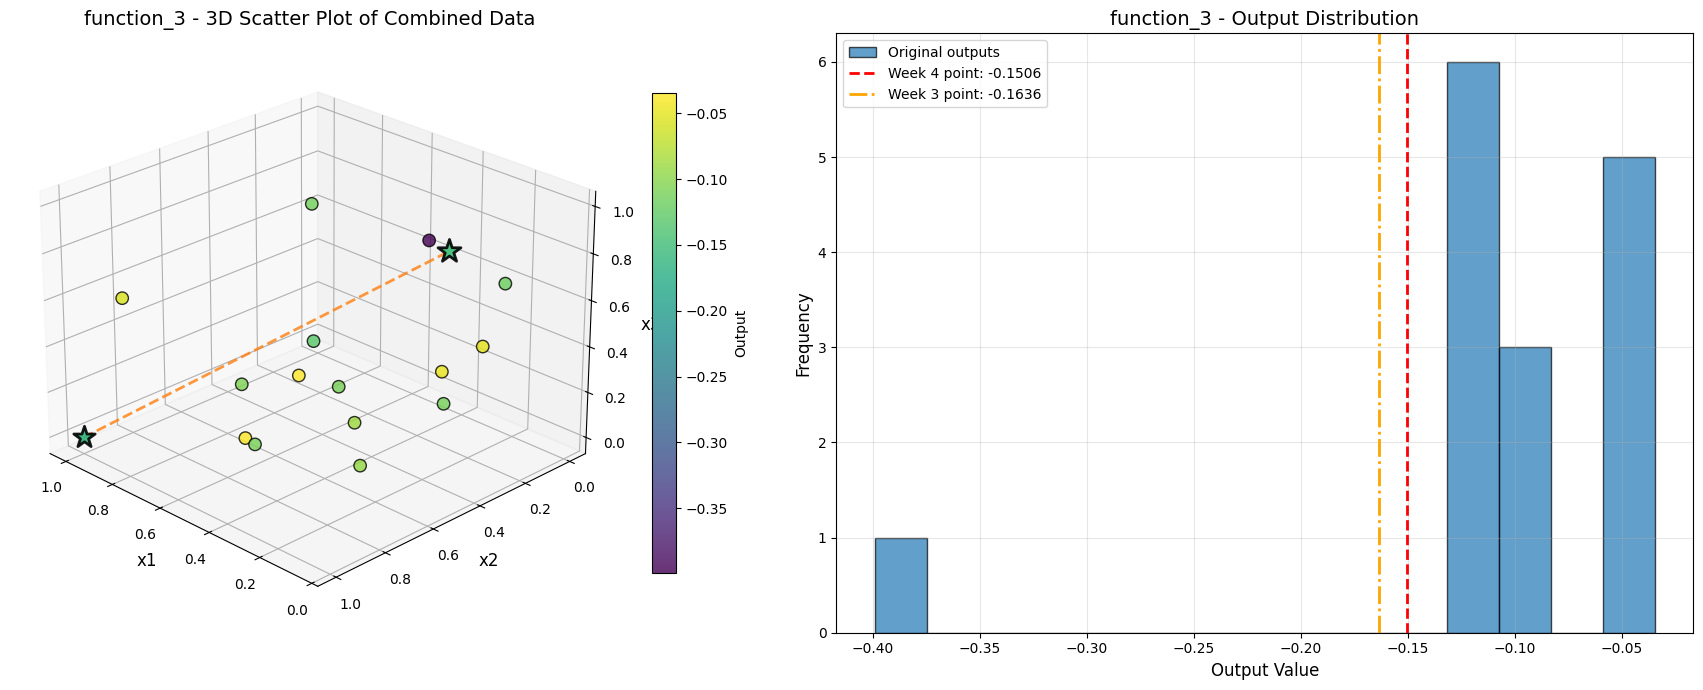

In [9]:
# Function 3 - Combine all data (initial + week 1 + week 2 + week 3 + week 4)
function_name = 'function_3'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output])
])

print("=" * 60)
print(f"FUNCTION 3 - COMBINED DATA")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print("=" * 60)

# Visualize: show week 3 and week 4 points
plot_3d_scatter_with_distribution(
    original_inputs, original_outputs,
    week4_input, week4_output,
    function_name,
    prior_input=week3_input,
    prior_output=week3_output,
    prior_point_label="Week 3 point",
    new_point_label="Week 4 point",
    connect_points=True,
    connect_color="tab:orange"
    
)

In [ ]:
# Function 3 - Run Exploitative Bayesian Optimization
function_name = 'function_3'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create BO object with beta=0 for pure exploitation
bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point using UCB with beta=0.0 (pure exploitation)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print(f"FUNCTION 3 - EXPLOITATIVE BO SUGGESTION (β=0)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0 = mean): {ucb_value:.6f}")
print("=" * 60)

# Save to JSON
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "exploitative_bayesian_optimization",
    "beta": 0.0,
    "expected_value": float(ucb_value)
}

output_path = 'results/function3_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")


FUNCTION 3 - EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.428006-0.895894-0.000000
Expected value (UCB with β=0 = mean): 0.060547

Result saved to: function3_next_point.json


### FUNCTION 4 - EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 4 - COMBINED DATA

Combined inputs shape: (34, 4)
Combined outputs shape: (34,)

Best observed output so far: 0.076352
Mean output: -16.041238
Std output: 8.253771


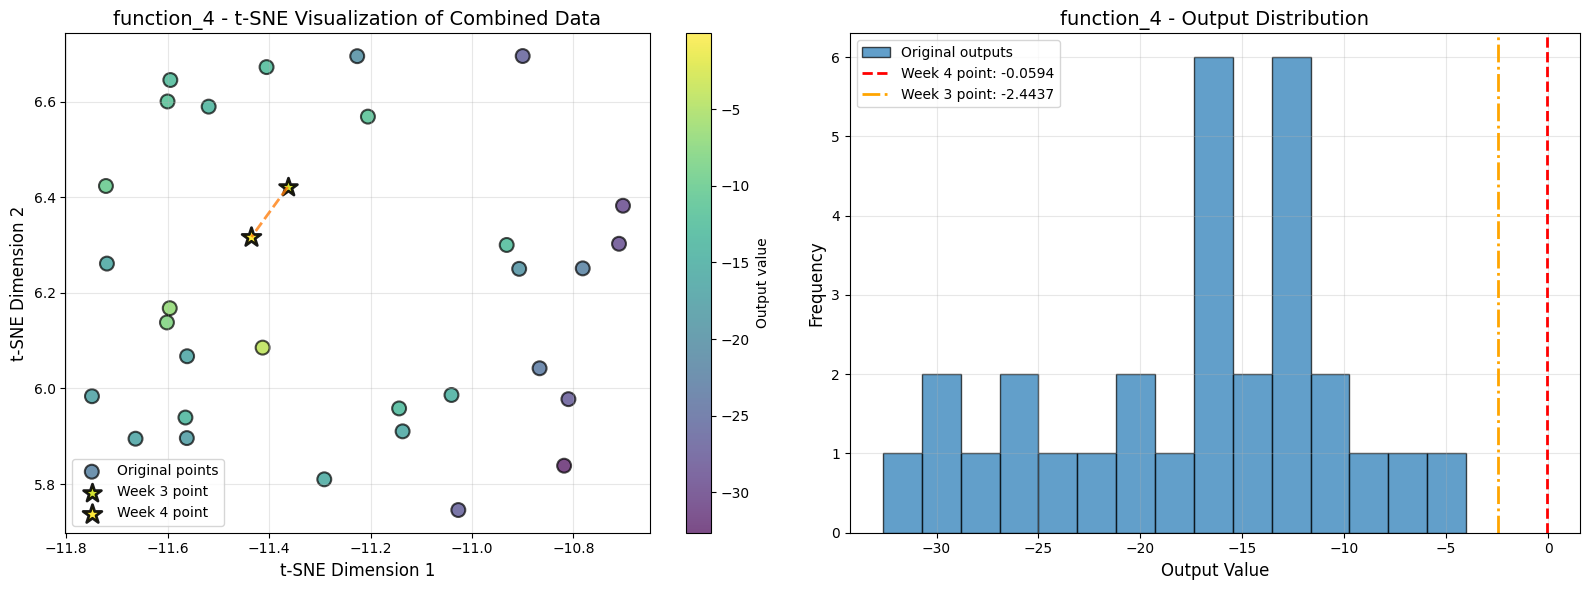

In [11]:
# Function 4 - Combine all data (initial + week 1 + week 2 + week 3 + week 4)
function_name = 'function_4'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output])
])

print("=" * 60)
print(f"FUNCTION 4 - COMBINED DATA")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print("=" * 60)

# Visualize: show week 3 and week 4 points
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    week4_input, week4_output,
    function_name,
    prior_input=week3_input,
    prior_output=week3_output,
    prior_point_label="Week 3 point",
    new_point_label="Week 4 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

In [ ]:
# Function 4 - Run Exploitative Bayesian Optimization
function_name = 'function_4'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create BO object with beta=0 for pure exploitation
bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point using UCB with beta=0.0 (pure exploitation)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print(f"FUNCTION 4 - EXPLOITATIVE BO SUGGESTION (β=0)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0 = mean): {ucb_value:.6f}")
print("=" * 60)

# Save to JSON
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "exploitative_bayesian_optimization",
    "beta": 0.0,
    "expected_value": float(ucb_value)
}

output_path = 'results/function4_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")


FUNCTION 4 - EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.414823-0.374605-0.392950-0.438650
Expected value (UCB with β=0 = mean): 0.466981

Result saved to: function4_next_point.json


### FUNCTION 5 - EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 5 - COMBINED DATA

Combined inputs shape: (24, 4)
Combined outputs shape: (24,)

Best observed output so far: 4219.157963
Mean output: 694.248424
Std output: 1351.994574


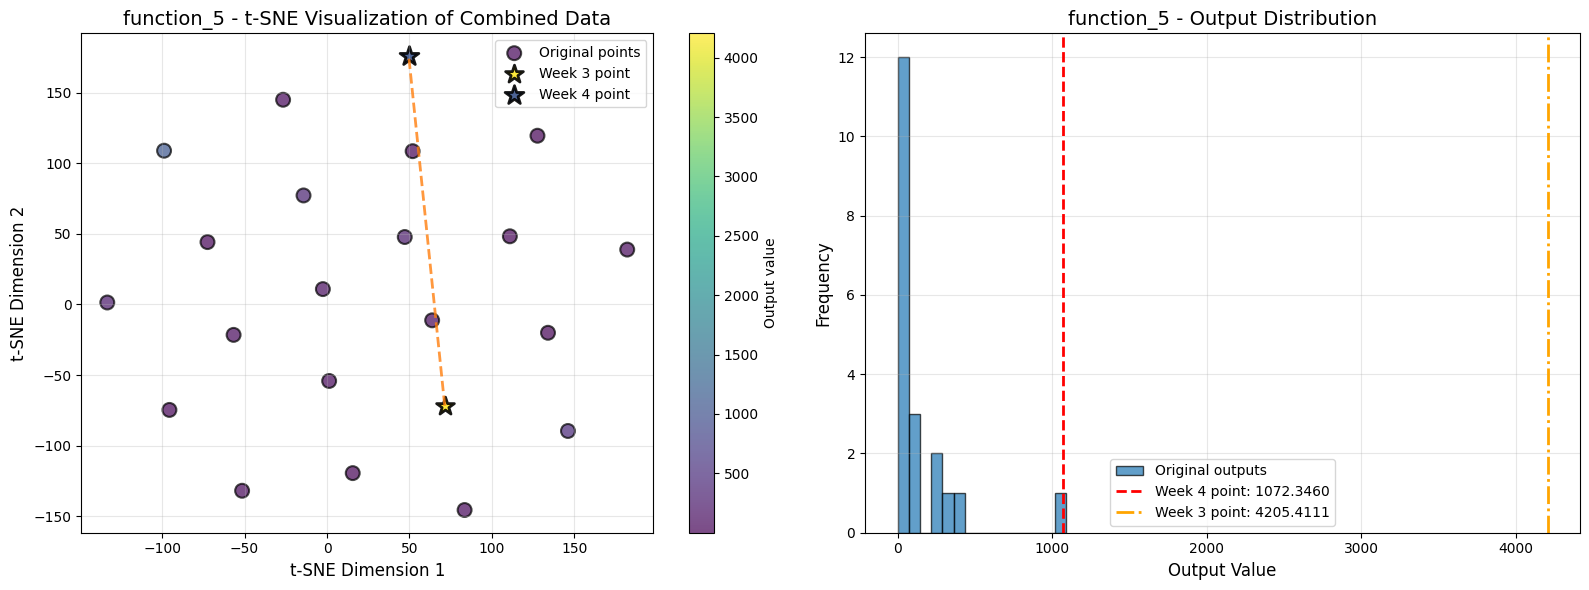

In [13]:
# Function 5 - Combine all data (initial + week 1 + week 2 + week 3 + week 4)
function_name = 'function_5'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output])
])

print("=" * 60)
print(f"FUNCTION 5 - COMBINED DATA")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print("=" * 60)

# Visualize: show week 3 and week 4 points
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    week4_input, week4_output,
    function_name,
    prior_input=week3_input,
    prior_output=week3_output,
    prior_point_label="Week 3 point",
    new_point_label="Week 4 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

In [ ]:
# Function 5 - Run Exploitative Bayesian Optimization
function_name = 'function_5'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create BO object with beta=0 for pure exploitation
bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point using UCB with beta=0.0 (pure exploitation)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print(f"FUNCTION 5 - EXPLOITATIVE BO SUGGESTION (β=0)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0 = mean): {ucb_value:.6f}")
print("=" * 60)

# Save to JSON
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "exploitative_bayesian_optimization",
    "beta": 0.0,
    "expected_value": float(ucb_value)
}

output_path = 'results/function5_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")


FUNCTION 5 - EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.229439-0.845664-0.891406-0.879969
Expected value (UCB with β=0 = mean): 1115.366095

Result saved to: function5_next_point.json


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### FUNCTION 6 - EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 6 - COMBINED DATA

Combined inputs shape: (24, 5)
Combined outputs shape: (24,)

Best observed output so far: -0.714265
Mean output: -1.564590
Std output: 0.486770


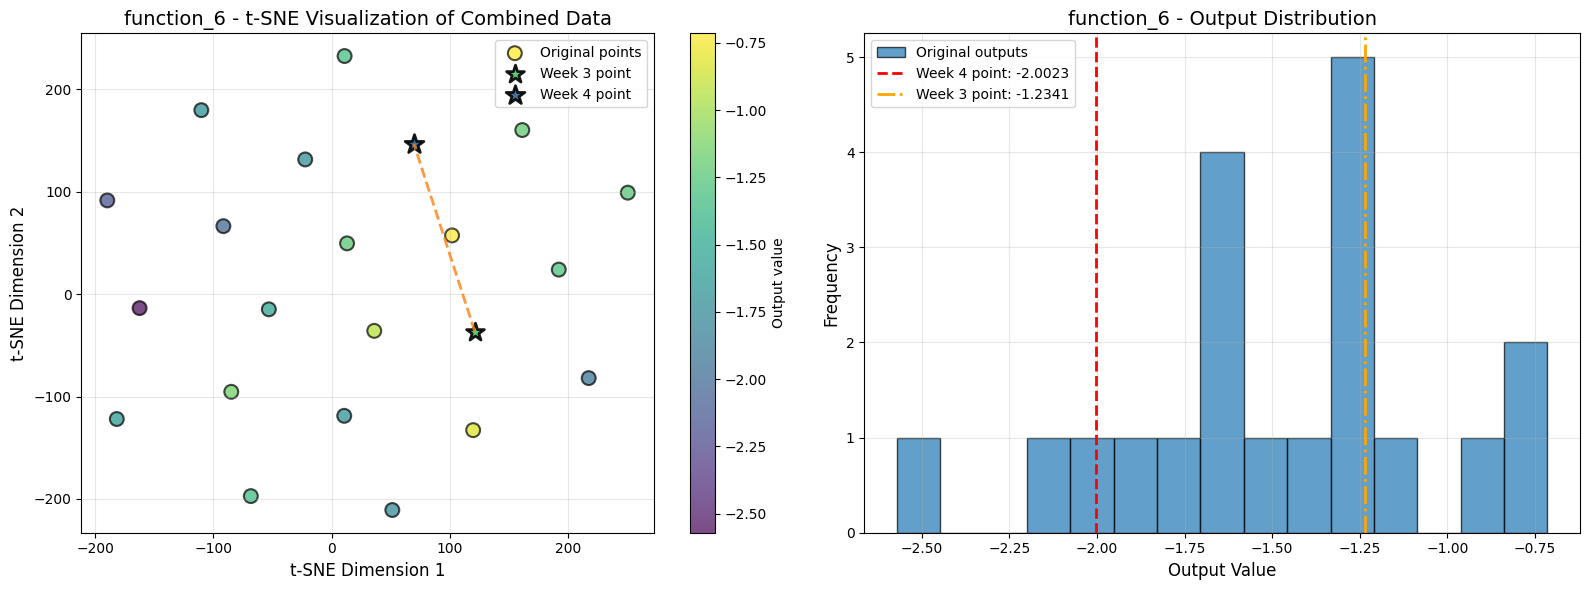

In [15]:
# Function 6 - Combine all data (initial + week 1 + week 2 + week 3 + week 4)
function_name = 'function_6'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output])
])

print("=" * 60)
print(f"FUNCTION 6 - COMBINED DATA")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print("=" * 60)

# Visualize: show week 3 and week 4 points
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    week4_input, week4_output,
    function_name,
    prior_input=week3_input,
    prior_output=week3_output,
    prior_point_label="Week 3 point",
    new_point_label="Week 4 point",
    connect_points=True,
    connect_color="tab:orange",
    random_state=TSNE_RANDOM_STATE
)

In [ ]:
# Function 6 - Run Exploitative Bayesian Optimization
function_name = 'function_6'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Create BO object with beta=0 for pure exploitation
bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)

# Fit GP to observed data
bo.fit(X_observed, y_observed)

# Suggest next point using UCB with beta=0.0 (pure exploitation)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

# Format for submission
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("\n" + "=" * 60)
print(f"FUNCTION 6 - EXPLOITATIVE BO SUGGESTION (β=0)")
print("=" * 60)
print(f"Suggested next point: {formatted_point}")
print(f"Expected value (UCB with β=0 = mean): {ucb_value:.6f}")
print("=" * 60)

# Save to JSON
result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "exploitative_bayesian_optimization",
    "beta": 0.0,
    "expected_value": float(ucb_value)
}

output_path = 'results/function6_next_point.json'
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f"\nResult saved to: {output_path}")


FUNCTION 6 - EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.444487-0.327460-0.525031-0.777595-0.205622
Expected value (UCB with β=0 = mean): -0.434780

Result saved to: function6_next_point.json


### SUMMARY - ALL FUNCTIONS

In [ ]:
# Print summary of all suggestions
print("=" * 60)
print("EXPLOITATIVE BAYESIAN OPTIMIZATION - SUMMARY")
print("Functions 2, 3, 4, 5, 6")
print("=" * 60)
print("\nMethod: Gaussian Process with UCB (β=0, pure exploitation)")
print("\nNext points for submission:")
print()

for func_num in range(2, 7):
    json_path = f'results/function{func_num}_next_point.json'
    if Path(json_path).exists():
        with open(json_path, 'r') as f:
            result = json.load(f)
            print(f"function_{func_num}: {result['formatted']}")
            print(f"  Expected value: {result['expected_value']:.6f}")
    else:
        print(f"function_{func_num}: [NOT GENERATED]")

print()
print("=" * 60)

EXPLOITATIVE BAYESIAN OPTIMIZATION - SUMMARY
Functions 2, 3, 4, 5, 6

Method: Gaussian Process with UCB (β=0, pure exploitation)

Next points for submission:

function_2: 0.696761-0.934107
  Expected value: 0.614920
function_3: 0.428006-0.895894-0.000000
  Expected value: 0.060547
function_4: 0.414823-0.374605-0.392950-0.438650
  Expected value: 0.466981
function_5: 0.229439-0.845664-0.891406-0.879969
  Expected value: 1115.366095
function_6: 0.444487-0.327460-0.525031-0.777595-0.205622
  Expected value: -0.434780

